In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

import torch
from torchvision.transforms import v2
from torchvision.io import decode_image

from scripts.preprocessing_scripts import run_pipeline, pipeline, get_class_weights, get_value_weights

# Initial Preprocessing Steps to make images easier to work with

As many images are quite large, repeatedly opening and processing them causes significant overhead. To minimize this effect, we do an initial preprocessing to resize and apply enhancements as necessary to the base images. Later, additional preprocessing actions will also occur within the PyTorch dataloader, but those are performed later to ensure the model does not overfit to a specific configuration of images.

Actions performed in this notebook:

* Image Preprocessing
    * Resizing of the images to 224x224
    * Additional enhancing of the images
* Saving each variation of the image in the respective folder

In [2]:
# EDIT DIRECTORY VARIABLES AS NEEDED
# --- Main Directory: contains all folders/files
root = "S:/CheXpert/"
# --- This is the original root listed on the csv file paths
old_root = "CheXpert-v1.0/train/"
old_test_root = "test/"

# --- Input directory variables
source_train_root1 = f"{root}raw_data/CheXpert-v1.0 batch 2 (train 1)/"
source_train_root2 = f"{root}raw_data/CheXpert-v1.0 batch 3 (train 2)/"
source_train_root3 = f"{root}raw_data/CheXpert-v1.0 batch 4 (train 3)/"
source_valid_rad_root = f"{root}raw_data/CheXpert-v1.0 batch 1 (validate & csv)/valid/"
source_test_rad_root = f"{root}raw_data/test/"

# --- Output directory variables
train_valid_root = f"{root}train_valid/"
test_root = f"{root}test/"
valid_rad_root = f"{root}valid_rad/" 
test_rad_root = f"{root}test_rad/"

# --- Filepaths for dfs
### If the full training dataset is not needed, use train_df_5000 or train_df_30000
train_df_filepath = f"{root}train_df.csv"
#
valid_df_filepath = f"{root}valid_df.csv"
test_df_filepath = f"{root}test_df.csv"
#
valid_rad_df_filepath = f"{root}valid_rad_df.csv"
test_rad_df_filepath = f"{root}test_rad_df.csv"

# --- Image size --> Include the desired image sizes in this list
dims = [224]

# --- Set seed for reproducibility (optional)
seed = 100
if seed:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [3]:
# Image enhancement variables
pipeline_kwargs = dict(
    scale_min=0,
    scale_max=255,
    usm_sigma=10,
    usm_weight=1.2,
    he_sigma=5,
    seed=seed
)

### Warning: This notebook will take a long time to process. To continue, set the below markers to True


In [61]:
# Choose the datasets to process
process_train_df = False ######################### This will take the longest out of all datasets
#
process_valid_df = False
process_test_df = False
#
process_valid_rad_df = False
process_test_rad_df = False

In [62]:
# Load the training/validation csvs
train_df = pd.read_csv(train_df_filepath)
valid_df = pd.read_csv(valid_df_filepath)
test_df = pd.read_csv(test_df_filepath)
valid_rad_df = pd.read_csv(valid_rad_df_filepath)
test_rad_df = pd.read_csv(test_rad_df_filepath)

print(f"# rows in train_df: {len(train_df)}")
print(f"# rows in valid_df: {len(valid_df)}")
print(f"# rows in test_df: {len(test_df)}")
print(f"# rows in valid_rad_df: {len(valid_rad_df)}")
print(f"# rows in test_rad_df: {len(test_rad_df)}")

# rows in train_df: 121302
# rows in valid_df: 30354
# rows in test_df: 39371
# rows in valid_rad_df: 202
# rows in test_rad_df: 0


## Preprocessing Steps:

* Scale the image values to the range [0-255]
<!-- * Crop out any border regions algorithmically -->
* Resize the training and validation images to (224x224)
<!-- * Find the 90-degree rotation which is closest to the average of a sample of 1000 x-ray images -->
* Convert the array to type uint8 for compatibility with Image
* Save the processed image as as jpeg file

### Preprocessing steps for enhanced images

* Scale the image values to the range [0-255]
<!-- * Crop out any border regions algorithmically -->
* Resize the training and validation images to (224x224)
<!-- * Find the 90-degree rotation which is closest to the average of a sample of 1000 x-ray images -->
* Sharpen the image using unsharp masking
* Equalize the histogram to increase contrast
* Convert the array to type uint8 for compatibility with Image
* Save the processed image as as jpeg file


These examples show the images going through the initial pipeline
These will be saved ahead of time to save time later with modelling

Image 1 ---> rotation90_angle = 180, rotation_angle = 41


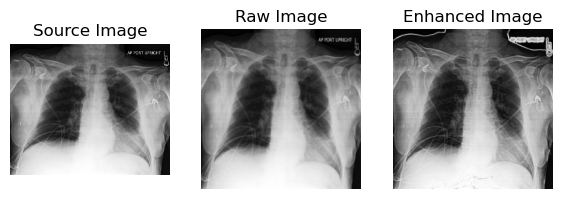

Image 2 ---> rotation90_angle = 180, rotation_angle = 41


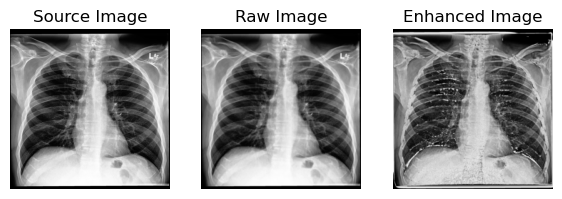

Image 3 ---> rotation90_angle = 180, rotation_angle = 41


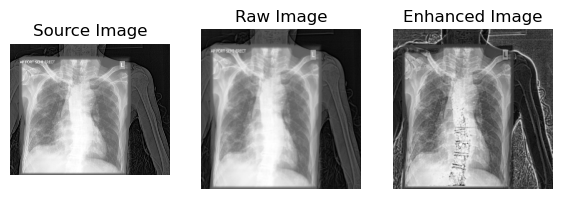

In [81]:
print("These examples show the images going through the initial pipeline")
print("These will be saved ahead of time to save time later with modelling")
print()

### Examples of images going through the pipeline
output_df = valid_rad_df.copy()
n_instances = len(output_df)

input_paths = output_df["source_file_path"]
output_path = output_df[f"base{str(dim)}_file_path"]
output_path2 = output_df[f"base{str(dim)}_file_path"].str[:-4] + "_usm.jpg"
#
for i,input_file_path in enumerate(input_paths, start=1):
    if i > 3: break
    print(f"Image {i} ---> rotation90_angle = {rotation90_angle}, rotation_angle = {rotation_angle}")
    #
    fig,ax = plt.subplots(1,3, figsize=(7,3))
    img, img_enhanced = pipeline(input_file_path, rotation90_angle=0, rotation_angle=0, training=True, **pipeline_kwargs)
    #
    with Image.open(input_file_path) as raw_img:
        ax[0].imshow(raw_img, cmap="gray")
        ax[0].set(title="Source Image")
        ax[0].axis("off")
    #
    ax[1].imshow(img, cmap="gray")
    ax[1].set(title="Raw Image")
    ax[1].axis("off")
    #
    ax[2].imshow(img_enhanced, cmap="gray")
    ax[2].set(title="Enhanced Image")
    ax[2].axis("off")
    plt.show()


These examples show the preprocessing performed in the dataloader during fitting
These added transformations add randomness to account for oversampling

Without these transformations, the model is more likely to be biased toward duplicate samples

A random center crop is added to help the model differentiate the lung from the background



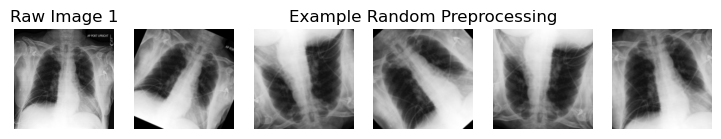

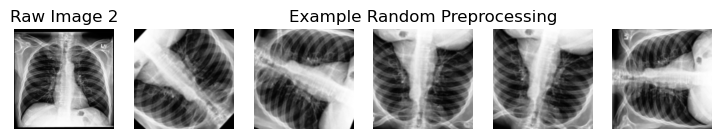

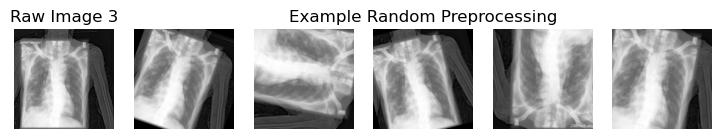

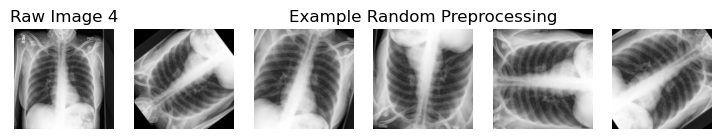

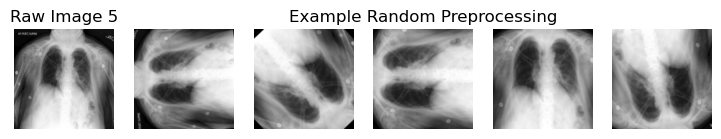

In [120]:
print("These examples show the preprocessing performed in the dataloader during fitting")
print("These added transformations add randomness to account for oversampling")
print()
print("Without these transformations, the model is more likely to be biased toward duplicate samples")
print()
print("A random center crop is added to help the model differentiate the lung from the background")
print()
### Visualizing the image transformations from the dataloader 
# This function is within the dataloader, but is copied here for direct reference
def random_preprocess(path, dim, rot90_k, random_float):
    img = decode_image(path)
    # Randomly rotate in a 90 degree interval
    img = torch.rot90(img, rot90_k, (1,2))
    #
    img = v2.functional.rotate(img, random_float[0]*30, interpolation=v2.InterpolationMode.BILINEAR)
    # Center crop and resize
    if np.abs(random_float[1]) > 1:
        img = v2.CenterCrop(dim - 16)(img)
        img = v2.Resize((dim,dim), interpolation=v2.InterpolationMode.BILINEAR)(img)
    elif np.abs(random_float[1]) > 0:
        img = v2.CenterCrop(dim - 48)(img)
        img = v2.Resize((dim,dim), interpolation=v2.InterpolationMode.BILINEAR)(img)
    return img

#####
output_df = valid_rad_df.copy()
n_examples = 5
#
n_instances = len(output_df)
input_paths = output_df[f"base{str(dim)}_file_path"]

for i,input_file_path in enumerate(input_paths, start=1):
    if i > 5: break
    rot90_k = np.random.choice(range(n_examples), n_instances, replace=True)
    random_float = np.random.randn(n_examples,2)
    #
    fig,axes = plt.subplots(1,n_examples+1, figsize=(9,2.5))
    imgs = [random_preprocess(input_file_path, dim, rot90_k=rot90_k[j], random_float=random_float[j,:]) for j in range(n_examples)]
    with Image.open(input_file_path) as raw_img:
        axes[0].imshow(raw_img, cmap="gray")
        axes[0].set(title=f"Raw Image {i}")
        axes[0].axis("off")
    axes[3].set(title="Example Random Preprocessing")
    for img,ax in zip(imgs, axes.flatten()[1:]):
        img = img.numpy().astype(np.uint8)[0,:,:]
        with Image.open(input_file_path) as raw_img:
            ax.imshow(img, cmap="gray")
            ax.axis("off")
    #
    # ax[1].imshow(img, cmap="gray")
    # ax[1].set(title="Input to ResNet")
    # ax[1].axis("off")

    plt.show()



### Process images

In [76]:
%%time
### Radiologist-labeled validation set
if process_valid_rad_df:
    for dim in dims:
        run_pipeline(valid_rad_df, dim=dim, training=False, skip_if_image_exists=True, **pipeline_kwargs)

CPU times: total: 0 ns
Wall time: 0 ns


In [77]:
%%time
### Radiologist-labeled test set
if process_test_rad_df:
    for dim in dims:
        run_pipeline(test_rad_df, dim=dim, training=False, skip_if_image_exists=True, **pipeline_kwargs)

CPU times: total: 0 ns
Wall time: 0 ns


In [78]:
%%time
### test set
if process_test_df:
    for dim in dims:
        run_pipeline(test_df, dim=dim, training=False, skip_if_image_exists=True, **pipeline_kwargs)

CPU times: total: 0 ns
Wall time: 0 ns


In [79]:
%%time
### validation set
if process_valid_df:
    for dim in dims:
        run_pipeline(valid_df, dim=dim, training=False, skip_if_image_exists=True, **pipeline_kwargs)

CPU times: total: 0 ns
Wall time: 0 ns


In [83]:
%%time
### training set
# Training is set to false as these preprocessing steps were moved to the dataloader instead
if process_train_df:
    for dim in dims:
        run_pipeline(train_df, dim=dim, training=False, skip_if_image_exists=True, **pipeline_kwargs)

CPU times: total: 0 ns
Wall time: 0 ns
